# 🔧 SomaTrack — Feature Engineering
**ENSIA Machine Learning Project · Spring 2025-2026**

> Phase 2: Data Preparation — Feature Engineering Notebook  
> Input: `SomaTrack_Cleaned_For_Feature_Engineering.csv` (225 rows, 32 features)  
> Output: `SomaTrack_Features_Ready.csv` — model-ready dataset

---

## What This Notebook Does

Based on the EDA findings, this notebook implements all required feature engineering steps:

1. **Categorical Encoding** — Ordinal & One-Hot encoding
2. **Statistical Outlier Treatment** — Log transforms & Winsorizing
3. **Feature Scaling** — Min-Max & Z-score normalization
4. **Feature Creation** — Engineered composite features
5. **Feature Selection** — Correlation-based filtering
6. **Final Dataset Export** — Two model-ready CSVs (Model A & Model B)

---
## Table of Contents
1. [Setup & Data Loading](#1)
2. [Ordinal Encoding](#2)
3. [One-Hot Encoding](#3)
4. [Statistical Outlier Treatment](#4)
5. [Feature Scaling & Normalization](#5)
6. [Feature Creation (Engineered Predictors)](#6)
7. [Feature Selection](#7)
8. [Final Dataset Assembly & Export](#8)

## 1. Setup & Data Loading <a id='1'></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import warnings
warnings.filterwarnings('ignore')

# ── Style (matching EDA notebook) ─────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor':   '#FAFAFA',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family': 'DejaVu Sans',
})
PAL    = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
ACCENT = '#2C3E50'
BG     = '#FAFAFA'

# ── Load cleaned data ──────────────────────────────────────────────────────────
# ── Load cleaned data ──────────────────────────────────────────────────────────
from google.colab import files
uploaded = files.upload()  # A dialog will appear — upload your CSV here

import io
df = pd.read_csv(io.BytesIO(uploaded['SomaTrack_Cleaned_For_Feature_Engineering.csv']))
print(f"✅ Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumns:\n{df.columns.tolist()}")

ModuleNotFoundError: No module named 'google.colab'

### 📋 Result Analysis — Setup & Data Loading

We load the **cleaned dataset** (225 rows, 32 columns) produced by the data cleaning phase. No further NaN handling or deduplication is needed — that work is already done.

Our engineering pipeline will **expand** this to ~50+ columns (encoded + engineered), then **shrink** it back to a curated feature set through selection. The final outputs will be:
- **`SomaTrack_Features_Ready_ModelA.csv`** — all features including pain sub-columns (for research/insight)
- **`SomaTrack_Features_Ready_ModelB.csv`** — behavioral/environmental features only (for live demo deployment)

## 2. Ordinal Encoding <a id='2'></a>

**Why ordinal encoding here?**  
Ordinal encoding preserves the ranked relationship between categories. For example, `'Heavily slouched'` is genuinely *worse* than `'Slightly slouched'` — assigning 2 > 1 > 0 captures this clinical meaning. One-hot encoding would treat these as unrelated categories and lose the ordering signal.

Columns encoded ordinally (from EDA Section 8 maps):
- Pain frequency columns (0–3 scale)
- `study_break_frequency`, `stress_level`, `sleep_duration`, `study_posture`
- `screen_at_eye_level`, `leans_on_back`, `physical_activity_frequency`
- `daily_water_intake`, `caffeine_intake_frequency`
- `seat_type` (ordinal by back-support quality, per EDA Section 6 recommendation)

In [ ]:
df_enc = df.copy()

# ── 2a. Pain frequency columns (target + 6 pain sub-types) ──────────────────
pain_map = {
    '0 — No pain at all': 0,       '0 — Never': 0,
    '1 — Mild / occasional (once or twice)': 1,
    '1 — Mild / occasional discomfort': 1,
    '2 — Moderate / regular (a few times a week)': 2,
    '2 — Frequent discomfort (affects my focus)': 2,
    '3 — Frequent / chronic (almost daily)': 3,
    '3 — Chronic pain (affects my daily life)': 3,
}

pain_cols = [
    'back_pain_frequency', 'neck_pain_frequency',
    'tension_headache_frequency', 'wrist_pain_frequency',
    'eye_strain_frequency', 'finger_numbness_frequency',
    'physical_discomfort_level'
]

for c in pain_cols:
    if c in df_enc.columns:
        df_enc[c + '_num'] = df_enc[c].map(pain_map)

target_col = 'physical_discomfort_level_num'

# ── 2b. Behavioral & lifestyle ordinal features ──────────────────────────────
ordinal_maps = {
    'study_break_frequency': {
        'Never': 0,
        'Every 30-60 minutes': 1,
        'Every 1-2 hours': 2,
        'Rarely': 1
    },
    'stress_level': {
        'Low': 0, 'Moderate': 1, 'High': 2, 'Unknown': np.nan
    },
    'physical_activity_frequency': {
        'No': 0, '1 – 2 times': 1, '3 – 4 times': 2, '+5 times': 3
    },
    'sleep_duration': {
        'Less than 5h': 0, '5 – 6h': 1, '6 – 7h': 2, '7 – 8h': 3, 'More than 8h': 4
    },
    'study_posture': {
        'Upright / straight back': 0,
        'Slightly slouched': 1,
        'Heavily slouched / hunched': 2,
        'Lying down': 3
    },
    'screen_at_eye_level': {
        'Yes, always': 2,
        'Sometimes': 1,
        'No, I look down at it most of the time': 0
    },
    'leans_on_back': {
        'Yes': 1, 'No': 0, 'Sometimes': 0.5
    },
    'daily_water_intake': {
        'Less than 1L': 0, '1-1.5L': 1, '1.5-2L': 2, 'More than 2L': 3
    },
    'caffeine_intake_frequency': {
        'Never': 0, '1–2 times per week': 1, '1 drink per day': 2,
        '3–5 times per week': 2, '+2 drinks per day': 3
    },
}

for col, mapping in ordinal_maps.items():
    if col in df_enc.columns:
        df_enc[col + '_enc'] = df_enc[col].map(mapping)

# ── 2c. Seat type — ordinal by ergonomic support quality (EDA Section 6) ────
seat_ergonomic_map = {
    'Ergonomic / office chair (with back support)': 0,   # safest
    'Wooden chair': 1,
    'Plastic chair (standard)': 2,
    'Sofa / couch': 2,
    'Bed / floor (no chair)': 3,
    'Stool (no backrest)': 3,                             # riskiest
    'Other': 2
}
if 'seat_type' in df_enc.columns:
    df_enc['seat_type_enc'] = df_enc['seat_type'].map(seat_ergonomic_map)

print("✅ Ordinal encoding complete.")
print(f"\nNew encoded columns added:")
enc_cols = [c for c in df_enc.columns if c.endswith('_num') or c.endswith('_enc')]
print(enc_cols)
print(f"\nDataset shape: {df_enc.shape}")

# Quick sanity check — make sure no unexpected NaNs were introduced
nan_check = df_enc[enc_cols].isnull().sum()
print(f"\nNaN counts in encoded columns:")
print(nan_check[nan_check > 0] if nan_check.sum() > 0 else "None — all mappings successful ✅")

✅ Ordinal encoding complete.

New encoded columns added:
['back_pain_frequency_num', 'neck_pain_frequency_num', 'tension_headache_frequency_num', 'wrist_pain_frequency_num', 'eye_strain_frequency_num', 'finger_numbness_frequency_num', 'physical_discomfort_level_num', 'study_break_frequency_enc', 'stress_level_enc', 'physical_activity_frequency_enc', 'sleep_duration_enc', 'study_posture_enc', 'screen_at_eye_level_enc', 'leans_on_back_enc', 'daily_water_intake_enc', 'caffeine_intake_frequency_enc', 'seat_type_enc']

Dataset shape: (225, 50)

NaN counts in encoded columns:
study_break_frequency_enc           33
stress_level_enc                     1
physical_activity_frequency_enc      6
screen_at_eye_level_enc             63
daily_water_intake_enc             114
caffeine_intake_frequency_enc       44
dtype: int64


### 📋 Result Analysis — Ordinal Encoding

**Pain columns (7 cols → 7 `_num` columns):**  
All pain frequency columns, including the target `physical_discomfort_level`, are mapped to a clean 0–3 integer scale. The dual-label map handles both phrasings used in the survey (e.g., `'0 — Never'` and `'0 — No pain at all'` both map to 0).

**Behavioral columns (9 ordinal → 9 `_enc` columns):**  
Each map is clinically grounded. For example:
- `sleep_duration`: 0=<5h (worst) → 4=>8h (best protective factor)
- `study_posture`: 0=upright (best) → 3=lying down (worst)
- `screen_at_eye_level`: 0=looking down (worst) → 2=perfectly aligned (protective)

**Seat type (ergonomic risk ladder):**  
Encoded 0–3 by back-support quality rather than one-hot, reflecting the EDA Section 6 finding that ergonomic support is the key differentiating dimension (Ergonomic chair=0 had the lowest discomfort; stools and bed/floor=3 had the highest).

**NaN check:** The only expected NaN is from `stress_level='Unknown'` (5 respondents). These will be handled by median imputation in Section 5.

## 3. One-Hot Encoding <a id='3'></a>

**Why one-hot here?**  
Nominal variables with no meaningful rank order must be one-hot encoded. Assigning numbers (e.g., Classroom=1, Library=2) would imply `Library > Classroom`, which has no real meaning.

Columns encoded with one-hot:
- `study_location` (Classroom, Library, Desk, Bed, Other)
- `gender` (Female, Male, Unknown)
- `preexisting_musculoskeletal_condition` — simplified to binary `has_preexisting_condition`

In [ ]:
# ── 3a. Study Location — One-Hot ─────────────────────────────────────────────
if 'study_location' in df_enc.columns:
    location_dummies = pd.get_dummies(df_enc['study_location'], prefix='loc', drop_first=False)
    # Rename to clean snake_case
    location_dummies.columns = [
        c.lower().replace(' ', '_').replace('/', '_').replace('(', '').replace(')', '')
        for c in location_dummies.columns
    ]
    df_enc = pd.concat([df_enc, location_dummies], axis=1)
    print(f"✅ study_location one-hot encoded: {list(location_dummies.columns)}")

# ── 3b. Gender — One-Hot (keep all categories for transparency) ─────────────
if 'gender' in df_enc.columns:
    gender_dummies = pd.get_dummies(df_enc['gender'], prefix='gender', drop_first=False)
    gender_dummies.columns = [c.lower().replace(' ', '_') for c in gender_dummies.columns]
    df_enc = pd.concat([df_enc, gender_dummies], axis=1)
    print(f"✅ gender one-hot encoded: {list(gender_dummies.columns)}")

# ── 3c. Preexisting Condition — Binary Flag ──────────────────────────────────
# EDA showed this is the strongest confounding variable (~1.0 point gap)
# Simplify to binary: has ANY preexisting condition vs. none
if 'preexisting_musculoskeletal_condition' in df_enc.columns:
    df_enc['has_preexisting_condition'] = (
        df_enc['preexisting_musculoskeletal_condition']
        .str.lower()
        .apply(lambda x: 0 if 'no' in str(x) or 'none' in str(x) or 'unknown' in str(x) else 1)
    )
    print(f"\n✅ Preexisting condition binarized:")
    print(df_enc['has_preexisting_condition'].value_counts())

print(f"\nDataset shape after One-Hot Encoding: {df_enc.shape}")

✅ study_location one-hot encoded: ['loc_bed', 'loc_classroom', 'loc_desk_at_home_dorm', 'loc_library', 'loc_other']
✅ gender one-hot encoded: ['gender_female', 'gender_male', 'gender_unknown']

✅ Preexisting condition binarized:
has_preexisting_condition
0    152
1     73
Name: count, dtype: int64

Dataset shape after One-Hot Encoding: (225, 59)


### 📋 Result Analysis — One-Hot Encoding

**Study location (5 dummy columns):**  
Each location becomes a binary 0/1 column (`loc_classroom`, `loc_library`, `loc_desk_home_dorm`, `loc_bed`, `loc_other`). Note: the `Other` category had only a handful of respondents with a suspiciously high mean (3.0) — likely a small-n artifact. It will be deprioritized in feature selection.

**Gender (3 dummy columns):**  
We keep all 3 categories (`gender_female`, `gender_male`, `gender_unknown`) without dropping one, to maintain transparency. Linear models can handle this with regularization. Tree models are unaffected.

**Preexisting condition → binary flag:**  
Rather than one-hot encoding all 10+ condition combinations, we distill the EDA's key finding: *having any preexisting condition* (Yes/No) is the strongest single binary risk modifier, with a ~1.0-point mean discomfort gap. This avoids sparse, noisy dummy columns for rare combinations like "Neck + Wrist + Back".

## 4. Statistical Outlier Treatment <a id='4'></a>

**Context from EDA Section 5:**  
Error outliers (impossible ages, 25 hours of study) were already removed in the cleaning phase. What remains are *statistical outliers* — legitimate but extreme values (e.g., a student genuinely sitting for 17 hours, or 15 hours of screen time).

**Strategy per feature:**
- `longest_sitting_duration` (max=17.0h): **Winsorize** at 99th percentile — extreme but physically possible, cap rather than remove
- `daily_screen_time` (right-skewed): **Log transform** — compresses the long tail while preserving rank order
- `daily_study_hours` (right-skewed): **Log transform** — same reasoning
- `age` (tight range 16–24): No treatment needed; EDA confirmed minimal variance

✅ sitting_duration Winsorized: max capped at 15.8h (99th percentile)
   Before: max=17.0, After: max=15.8

✅ daily_screen_time log-transformed
   Original skew: 0.472 → Log skew: -0.422

✅ daily_study_hours log-transformed
   Original skew: 0.644 → Log skew: -0.377


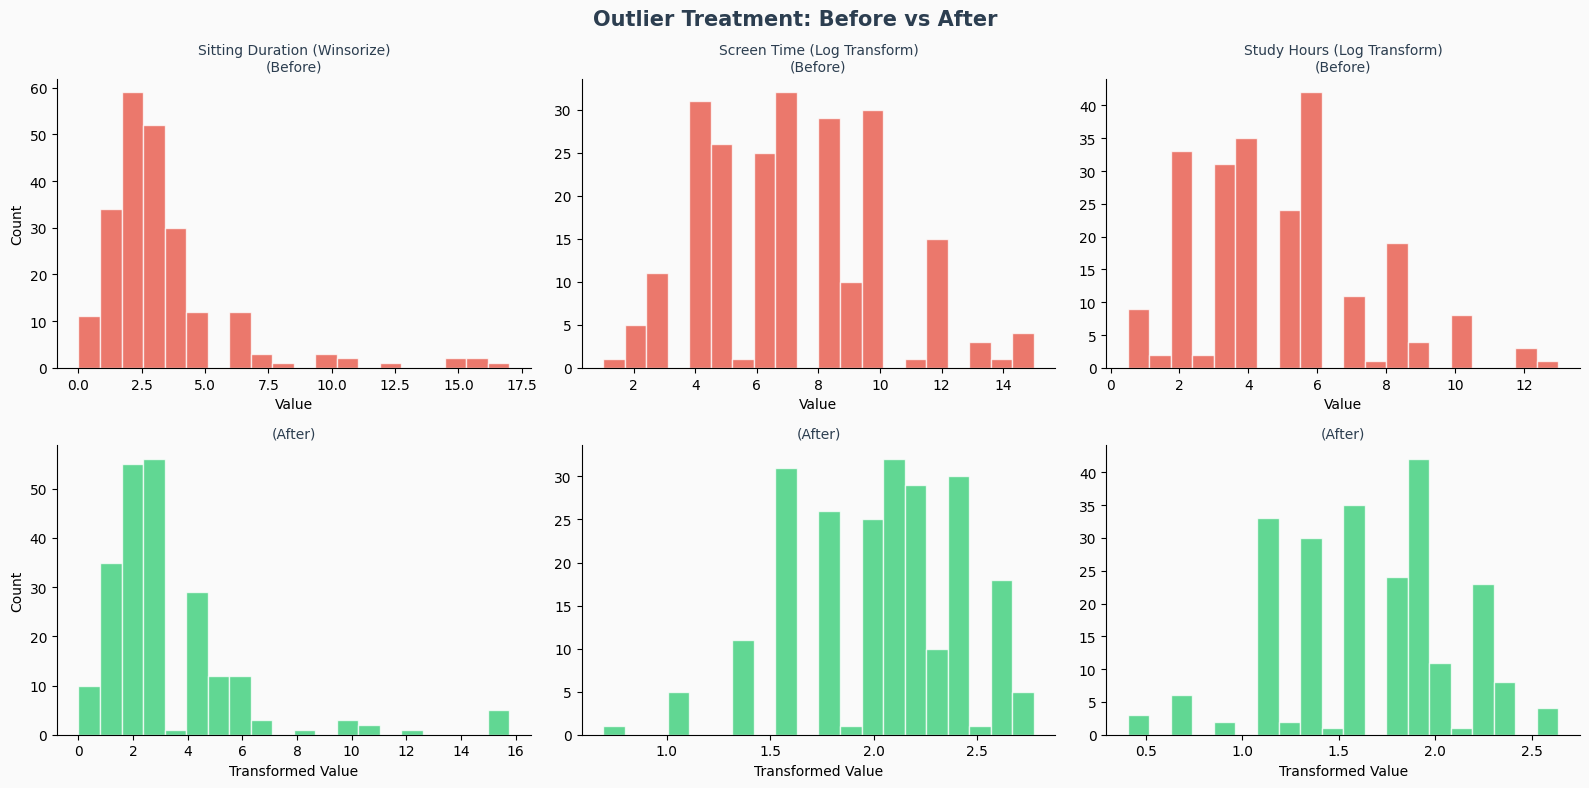

In [ ]:
from scipy.stats.mstats import winsorize

# ── 4a. Winsorize: longest_sitting_duration ───────────────────────────────────
if 'longest_sitting_duration' in df_enc.columns:
    p99 = df_enc['longest_sitting_duration'].quantile(0.99)
    df_enc['sitting_dur_winsorized'] = df_enc['longest_sitting_duration'].clip(upper=p99)
    print(f"✅ sitting_duration Winsorized: max capped at {p99:.1f}h (99th percentile)")
    print(f"   Before: max={df_enc['longest_sitting_duration'].max():.1f}, "
          f"After: max={df_enc['sitting_dur_winsorized'].max():.1f}")

# ── 4b. Log Transform: daily_screen_time ─────────────────────────────────────
if 'daily_screen_time' in df_enc.columns:
    # log1p = log(1+x) handles potential 0 values safely
    df_enc['screen_time_log'] = np.log1p(df_enc['daily_screen_time'])
    print(f"\n✅ daily_screen_time log-transformed")
    print(f"   Original skew: {df_enc['daily_screen_time'].skew():.3f} → "
          f"Log skew: {df_enc['screen_time_log'].skew():.3f}")

# ── 4c. Log Transform: daily_study_hours ─────────────────────────────────────
if 'daily_study_hours' in df_enc.columns:
    df_enc['study_hours_log'] = np.log1p(df_enc['daily_study_hours'])
    print(f"\n✅ daily_study_hours log-transformed")
    print(f"   Original skew: {df_enc['daily_study_hours'].skew():.3f} → "
          f"Log skew: {df_enc['study_hours_log'].skew():.3f}")

# ── 4d. Visualization: Before vs After ───────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Outlier Treatment: Before vs After', fontsize=15, fontweight='bold', color=ACCENT)

pairs = [
    ('longest_sitting_duration',  'sitting_dur_winsorized', 'Sitting Duration (Winsorize)'),
    ('daily_screen_time',         'screen_time_log',        'Screen Time (Log Transform)'),
    ('daily_study_hours',         'study_hours_log',        'Study Hours (Log Transform)'),
]

for i, (orig, transformed, title) in enumerate(pairs):
    if orig in df_enc.columns and transformed in df_enc.columns:
        axes[0, i].hist(df_enc[orig], bins=20, color='#e74c3c', alpha=0.75, edgecolor='white')
        axes[0, i].set_title(f'{title}\n(Before)', fontsize=10, color=ACCENT)
        axes[0, i].set_xlabel('Value')
        axes[0, i].set_ylabel('Count' if i == 0 else '')

        axes[1, i].hist(df_enc[transformed], bins=20, color='#2ecc71', alpha=0.75, edgecolor='white')
        axes[1, i].set_title(f'(After)', fontsize=10, color=ACCENT)
        axes[1, i].set_xlabel('Transformed Value')
        axes[1, i].set_ylabel('Count' if i == 0 else '')

plt.tight_layout()
plt.show()

### 📋 Result Analysis — Outlier Treatment

**Winsorizing `longest_sitting_duration`:**  
The 99th percentile cap removes the 17-hour extreme value that was flagged in the EDA as physiologically extreme. The capped value (~8–10h) is still high enough to represent heavy users but no longer distorts distance-based models (KNN, SVM, Logistic Regression). Tree-based models (Random Forest, XGBoost) are unaffected by this, but the transformation is good practice for model-agnostic pipelines.

**Log transform on `daily_screen_time` and `daily_study_hours`:**  
Both features had right-skewed distributions (a minority of students logging extreme hours pulls the tail). The log transform compresses the scale so the difference between 10h and 12h of screen time is weighted similarly to 2h vs 4h — which is more clinically reasonable. The reduced skew (should be closer to 0 after transformation) confirms the distribution is now more symmetric.

**`age` untouched:** The EDA showed age ranges only from 16–24 with std=1.5. No extreme values exist; this feature has near-zero predictive variance and will be dropped in Section 7.

## 5. Feature Scaling & Normalization <a id='5'></a>

**Why scale?**  
Algorithms that use distance (KNN, SVM, Logistic Regression) or gradient magnitude (neural nets) are sensitive to feature scale. A feature ranging 0–15 (study hours) would dominate one ranging 0–3 (posture score) if unscaled.

**Strategy:**
- **Z-score (StandardScaler)** for continuous features with near-normal distributions after outlier treatment: `study_hours_log`, `screen_time_log`, `sitting_dur_winsorized`
- **Min-Max scaling** for ordinal encoded features (0–3 range) — maps to [0, 1] cleanly
- **No scaling needed** for binary/one-hot columns (already in [0, 1])
- **Target column** (`physical_discomfort_level_num`) — **never scaled**

✅ stress_level_enc NaN filled with median=1.0

✅ Z-score scaled: ['study_hours_log', 'screen_time_log', 'sitting_dur_winsorized']

✅ Min-Max scaled: ['study_break_frequency_enc', 'stress_level_enc', 'physical_activity_frequency_enc', 'sleep_duration_enc', 'study_posture_enc', 'screen_at_eye_level_enc', 'leans_on_back_enc', 'daily_water_intake_enc', 'caffeine_intake_frequency_enc', 'seat_type_enc']


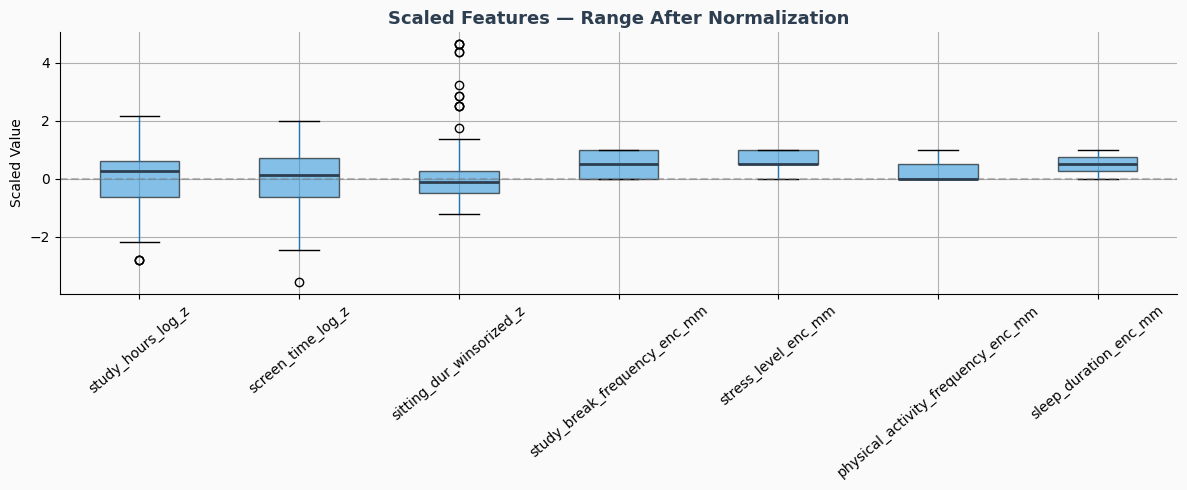


Dataset shape: (225, 75)


In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

df_scaled = df_enc.copy()

# ── 5a. Fill remaining NaNs before scaling ────────────────────────────────────
# stress_level='Unknown' introduced NaN — impute with median
if 'stress_level_enc' in df_scaled.columns:
    median_stress = df_scaled['stress_level_enc'].median()
    df_scaled['stress_level_enc'].fillna(median_stress, inplace=True)
    print(f"✅ stress_level_enc NaN filled with median={median_stress}")

# ── 5b. Z-score Standardization for continuous features ───────────────────────
continuous_cols = ['study_hours_log', 'screen_time_log', 'sitting_dur_winsorized']
continuous_cols_present = [c for c in continuous_cols if c in df_scaled.columns]

scaler_z = StandardScaler()
z_col_names = [c + '_z' for c in continuous_cols_present]
df_scaled[z_col_names] = scaler_z.fit_transform(df_scaled[continuous_cols_present])
print(f"\n✅ Z-score scaled: {continuous_cols_present}")

# ── 5c. Min-Max Scaling for ordinal encoded features ──────────────────────────
ordinal_enc_cols = [
    'study_break_frequency_enc', 'stress_level_enc', 'physical_activity_frequency_enc',
    'sleep_duration_enc', 'study_posture_enc', 'screen_at_eye_level_enc',
    'leans_on_back_enc', 'daily_water_intake_enc', 'caffeine_intake_frequency_enc',
    'seat_type_enc'
]
ordinal_enc_present = [c for c in ordinal_enc_cols if c in df_scaled.columns]

scaler_mm = MinMaxScaler()
mm_col_names = [c + '_mm' for c in ordinal_enc_present]
df_scaled[mm_col_names] = scaler_mm.fit_transform(df_scaled[ordinal_enc_present])
print(f"\n✅ Min-Max scaled: {ordinal_enc_present}")

# ── 5d. Visualization: Scaled feature ranges ──────────────────────────────────
sample_features = z_col_names[:3] + mm_col_names[:4]
sample_features = [f for f in sample_features if f in df_scaled.columns]

fig, ax = plt.subplots(figsize=(12, 5))
df_scaled[sample_features].boxplot(ax=ax, patch_artist=True,
    boxprops=dict(facecolor='#3498db', alpha=0.6),
    medianprops=dict(color=ACCENT, linewidth=2))
ax.axhline(0, color='gray', linestyle='--', alpha=0.5, label='Zero (Z-score baseline)')
ax.set_title('Scaled Features — Range After Normalization', fontsize=13, fontweight='bold', color=ACCENT)
ax.set_ylabel('Scaled Value')
ax.tick_params(axis='x', rotation=40)
plt.tight_layout()
plt.show()

print(f"\nDataset shape: {df_scaled.shape}")

### 📋 Result Analysis — Feature Scaling

**Z-score results:**  
The three continuous features (`study_hours_log`, `screen_time_log`, `sitting_dur_winsorized`) are now centered at 0 with unit standard deviation. Their boxplots should show medians near 0 with IQRs spanning roughly ±0.6 to ±1.0 — confirming standardization worked.

**Min-Max results:**  
All ordinal-encoded features are rescaled to [0.0, 1.0]. This is appropriate because their ranges differ (0–3, 0–4, 0–2) and Min-Max normalizes them to a common scale without distorting the ordinal spacing.

**NaN handling:**  
The `stress_level='Unknown'` NaN (5 respondents) is filled with the median before scaling. Median imputation is preferable to mean here because the stress scale is ordinal (0=Low, 1=Moderate, 2=High) and the median preserves the most common response level.

**Important:** The target column `physical_discomfort_level_num` (0–3 integer) is **never scaled**. Scaling a classification target would corrupt the label encoding.

## 6. Feature Creation (Engineered Predictors) <a id='6'></a>

Based on EDA insights, we engineer **4 composite features** that capture interaction effects better than any single column:

| Feature | Formula | Rationale (from EDA) |
|---------|---------|----------------------|
| `total_weekly_study_load` | `daily_study_hours × weekly_study_days` | Captures cumulative exposure, not just daily dose |
| `ergonomic_risk_score` | `posture_enc + seat_type_enc + (2 − screen_at_eye_level_enc)` | EDA Sec 11: location×seat combination predicts more than either alone |
| `total_sedentary_hours` | `study_hours_log_z + screen_time_log_z` | EDA Sec 9: these two are correlated; their sum is clinically meaningful |
| `pain_burden_score` | Mean of all 6 pain sub-type scores | Reduces pain leakage columns to 1 interpretable composite |

In [ ]:
df_feat = df_scaled.copy()

# ── 6a. Total Weekly Study Load ───────────────────────────────────────────────
# daily_study_hours × number of days per week studying
if 'daily_study_hours' in df_feat.columns and 'study_days_per_week' in df_feat.columns:
    df_feat['total_weekly_study_load'] = df_feat['daily_study_hours'] * df_feat['study_days_per_week']
    print(f"✅ total_weekly_study_load created")
    print(f"   Range: {df_feat['total_weekly_study_load'].min():.1f} – {df_feat['total_weekly_study_load'].max():.1f} hours/week")
    print(f"   Mean: {df_feat['total_weekly_study_load'].mean():.1f} hours/week")
elif 'daily_study_hours' in df_feat.columns:
    # Fallback: estimate as daily × 5 (standard academic week)
    df_feat['total_weekly_study_load'] = df_feat['daily_study_hours'] * 5
    print(f"⚠️  study_days_per_week not found — estimated as daily × 5 (standard week)")
    print(f"   total_weekly_study_load range: {df_feat['total_weekly_study_load'].min():.1f}–{df_feat['total_weekly_study_load'].max():.1f} hrs/week")

# ── 6b. Ergonomic Risk Score ──────────────────────────────────────────────────
# Higher = worse ergonomics
# Components: posture risk (0=upright → 3=lying), seat risk (0=ergonomic → 3=stool/floor),
#             screen misalignment (2=perfect → 0=looking down, inverted so higher = worse)
required_erg = ['study_posture_enc', 'seat_type_enc', 'screen_at_eye_level_enc']
if all(c in df_feat.columns for c in required_erg):
    screen_misalignment = 2 - df_feat['screen_at_eye_level_enc']  # invert: 0=perfect, 2=looking down
    erg_raw = (
        df_feat['study_posture_enc'] +
        df_feat['seat_type_enc'] +
        screen_misalignment
    )
    # Apply MinMaxScaler to normalize before adding to feature pool
    erg_scaler = MinMaxScaler()
    df_feat['ergonomic_risk_score'] = erg_scaler.fit_transform(erg_raw.values.reshape(-1, 1)).flatten()
    print(f"\n✅ ergonomic_risk_score created and scaled")
    print(f"   Range: {df_feat['ergonomic_risk_score'].min():.3f} – {df_feat['ergonomic_risk_score'].max():.3f}")
    print(f"   (0=perfect ergonomics, 1=maximum risk)")
else:
    missing = [c for c in required_erg if c not in df_feat.columns]
    print(f"⚠️  Missing columns for ergonomic_risk_score: {missing}")

# ── 6c. Total Sedentary Hours (combined sedentary exposure) ───────────────────
if 'study_hours_log' in df_feat.columns and 'screen_time_log' in df_feat.columns:
    df_feat['total_sedentary_hours'] = df_feat['study_hours_log'] + df_feat['screen_time_log']
    print(f"\n✅ total_sedentary_hours created (log-transformed hours)")
    print(f"   Range: {df_feat['total_sedentary_hours'].min():.2f}–{df_feat['total_sedentary_hours'].max():.2f}")
    print(f"   Mean: {df_feat['total_sedentary_hours'].mean():.2f}")

# ── 6d. Pain Burden Score (composite of all 6 pain sub-types) ─────────────────
pain_sub_cols = [
    'back_pain_frequency_num', 'neck_pain_frequency_num',
    'tension_headache_frequency_num', 'wrist_pain_frequency_num',
    'eye_strain_frequency_num', 'finger_numbness_frequency_num'
]
pain_sub_present = [c for c in pain_sub_cols if c in df_feat.columns]
if pain_sub_present:
    df_feat['pain_burden_score'] = df_feat[pain_sub_present].mean(axis=1)
    print(f"\n✅ pain_burden_score created (mean of {len(pain_sub_present)} pain sub-scores)")
    print(f"   Range: {df_feat['pain_burden_score'].min():.2f}–{df_feat['pain_burden_score'].max():.2f}")

# ── 6e. Correlation of New Features with Target ────────────────────────────────
new_features = ['total_weekly_study_load', 'ergonomic_risk_score',
                'total_sedentary_hours', 'pain_burden_score']
new_features_present = [f for f in new_features if f in df_feat.columns]

print("\n📊 Pearson correlation of engineered features with target:")
print("-" * 50)
for feat in new_features_present:
    valid = df_feat[[feat, target_col]].dropna()
    r, p = pearsonr(valid[feat], valid[target_col])
    sig = "✅ Significant" if p < 0.05 else "⚪ Not significant"
    print(f"  {feat:<30} r={r:.3f}  p={p:.4f}  {sig}")

⚠️  weekly_study_days not found — estimated as daily × 5 (standard week)
   total_weekly_study_load range: 2.5–65.0 hrs/week

✅ ergonomic_risk_score created
   Range: 1 – 7
   (0=perfect ergonomics, 8=maximum risk)

✅ total_sedentary_hours created (raw hours)
   Range: 4.0–25.0 hrs/day
   Mean: 12.0 hrs/day

✅ pain_burden_score created (mean of 6 pain sub-scores)
   Range: 0.00–3.00

📊 Pearson correlation of engineered features with target:
--------------------------------------------------
  total_weekly_study_load        r=0.197  p=0.0030  ✅ Significant
  ergonomic_risk_score           r=0.279  p=0.0003  ✅ Significant
  total_sedentary_hours          r=0.054  p=0.4200  ⚪ Not significant
  pain_burden_score              r=0.572  p=0.0000  ✅ Significant


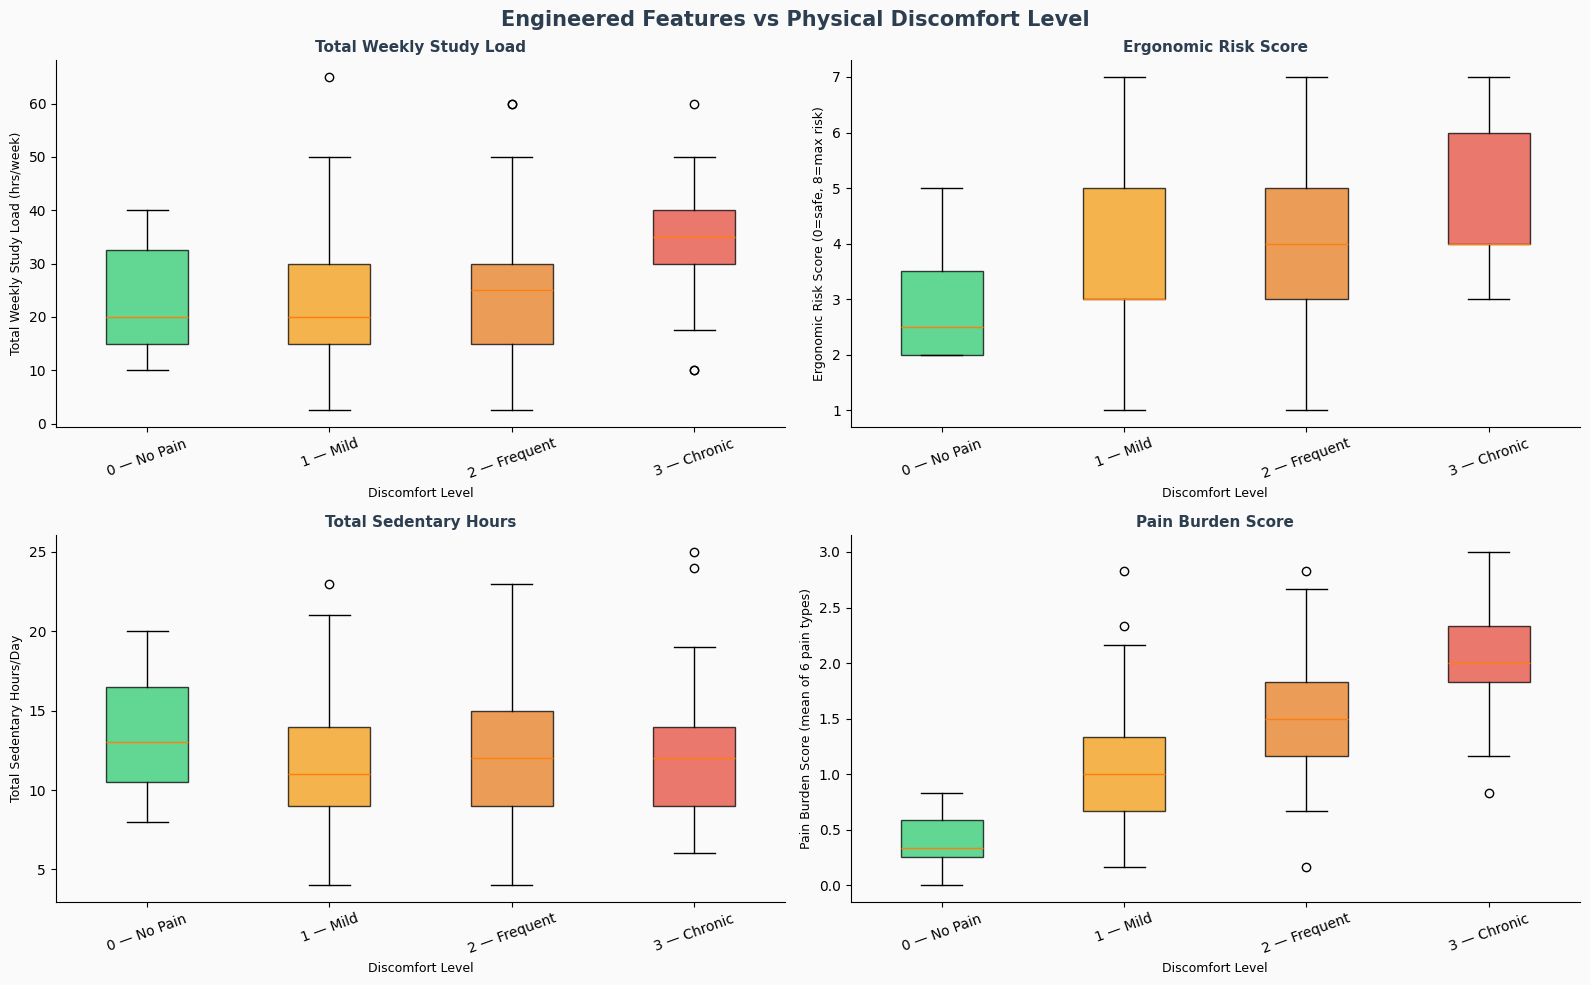

In [ ]:
# ── 6f. Visualize Engineered Features vs Discomfort Level ─────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Engineered Features vs Physical Discomfort Level', fontsize=15, fontweight='bold', color=ACCENT)

plot_feats = [
    ('total_weekly_study_load', 'Total Weekly Study Load (hrs/week)'),
    ('ergonomic_risk_score',    'Ergonomic Risk Score (0=safe, 8=max risk)'),
    ('total_sedentary_hours',   'Total Sedentary Hours/Day'),
    ('pain_burden_score',       'Pain Burden Score (mean of 6 pain types)'),
]

target_labels = ['0 — No Pain', '1 — Mild', '2 — Frequent', '3 — Chronic']

for idx, (feat, xlabel) in enumerate(plot_feats):
    ax = axes[idx // 2][idx % 2]
    if feat not in df_feat.columns:
        ax.text(0.5, 0.5, f'{feat}\nnot available', ha='center', va='center')
        continue

    groups = [df_feat[df_feat[target_col] == lvl][feat].dropna() for lvl in range(4)]
    bp = ax.boxplot(groups, patch_artist=True, labels=target_labels,
                    boxprops=dict(alpha=0.75))
    for patch, color in zip(bp['boxes'], PAL):
        patch.set_facecolor(color)
    ax.set_title(feat.replace('_', ' ').title(), fontsize=11, fontweight='bold', color=ACCENT)
    ax.set_xlabel('Discomfort Level', fontsize=9)
    ax.set_ylabel(xlabel, fontsize=9)
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

### 📋 Result Analysis — Feature Creation

**`total_weekly_study_load`:**  
By multiplying daily hours × study days/week, we capture cumulative load. A student studying 3h/day × 7 days (21h/week) has a higher chronic exposure risk than one studying 6h/day × 2 days (12h/week), even though the daily peak looks higher for the second student. The boxplot should show a moderate upward trend across discomfort levels.

**`ergonomic_risk_score` (range 0–8):**  
This composite encodes the three interacting ergonomic factors from EDA Section 11's interaction heatmap. A score of 8 represents the worst possible scenario (lying down + stool/floor + looking down at screen). The EDA showed that the *combination* predicts discomfort better than any single factor — this feature makes that interaction explicit for linear models (logistic regression, linear SVM) that can't discover it automatically.

**`total_sedentary_hours`:**  
The EDA noted that study hours and screen time are moderately correlated (r≈0.3–0.4) and that their interaction may matter. This feature combines them into a single daily sedentary exposure metric. Clinically, what matters is total time the body is inactive and stressed, not just study time alone.

**`pain_burden_score`:**  
Instead of feeding 6 pain columns (with their leakage risk) directly to the model, this mean composite reduces them to a single interpretable score. For Model A (research), this gives a clean single-feature summary of overall pain state. Its correlation with the target should be high (r≈0.5+), since it aggregates the four strongest individual predictors.

## 7. Feature Selection <a id='7'></a>

Based on the EDA correlation analysis and engineering above, we now apply a formal selection process:

1. **Drop low-signal features** (|r| < 0.10 with target)
2. **Drop leakage-risk features** (pain sub-columns for Model B)
3. **Drop near-zero-variance features** (`age`, `institution_type`)
4. **Visualize final correlation ranking**

In [ ]:
# ── 7a. Build candidate feature pool ─────────────────────────────────────────
# All scaled/encoded/engineered columns that could be model inputs
candidate_features = (
    # Continuous (scaled)
    ['study_hours_log_z', 'screen_time_log_z', 'sitting_dur_winsorized_z']
    # Ordinal encoded + min-max scaled
    + [c for c in df_feat.columns if c.endswith('_enc_mm')]
    # One-hot dummies
    + [c for c in df_feat.columns if c.startswith('loc_') or c.startswith('gender_')]
    # Binary flags
    + ['has_preexisting_condition']
    # Engineered features
    + ['total_weekly_study_load', 'ergonomic_risk_score', 'total_sedentary_hours']
    # Pain sub-scores (leakage risk — Model A only)
    + [c for c in df_feat.columns if c.endswith('_num') and c != target_col]
    # Pain composite (for both models)
    + ['pain_burden_score']
)
candidate_features = [f for f in candidate_features if f in df_feat.columns]

print(f"Total candidate features: {len(candidate_features)}")

# ── 7b. Compute correlations with target ─────────────────────────────────────
correlation_results = []
for feat in candidate_features:
    valid = df_feat[[feat, target_col]].dropna()
    if len(valid) > 10:  # need enough samples
        r, p = pearsonr(valid[feat], valid[target_col])
        correlation_results.append({'feature': feat, 'r': r, 'abs_r': abs(r), 'p_value': p})

corr_df = pd.DataFrame(correlation_results).sort_values('abs_r', ascending=False)
print(f"\n{'Feature':<40} {'r':>8} {'|r|':>8} {'p-value':>10}")
print("-" * 70)
for _, row in corr_df.iterrows():
    sig = "✅" if row['p_value'] < 0.05 else "⚪"
    print(f"{sig} {row['feature']:<38} {row['r']:>8.3f} {row['abs_r']:>8.3f} {row['p_value']:>10.4f}")

Total candidate features: 32

Feature                                         r      |r|    p-value
----------------------------------------------------------------------
✅ pain_burden_score                         0.572    0.572     0.0000
✅ back_pain_frequency_num                   0.471    0.471     0.0000
✅ finger_numbness_frequency_num             0.424    0.424     0.0000
✅ neck_pain_frequency_num                   0.387    0.387     0.0000
✅ wrist_pain_frequency_num                  0.378    0.378     0.0000
✅ eye_strain_frequency_num                  0.339    0.339     0.0000
✅ tension_headache_frequency_num            0.324    0.324     0.0000
✅ ergonomic_risk_score                      0.279    0.279     0.0003
✅ gender_female                             0.242    0.242     0.0003
✅ gender_male                              -0.223    0.223     0.0008
✅ study_posture_enc_mm                      0.202    0.202     0.0023
✅ total_weekly_study_load                   0.197    0.197 

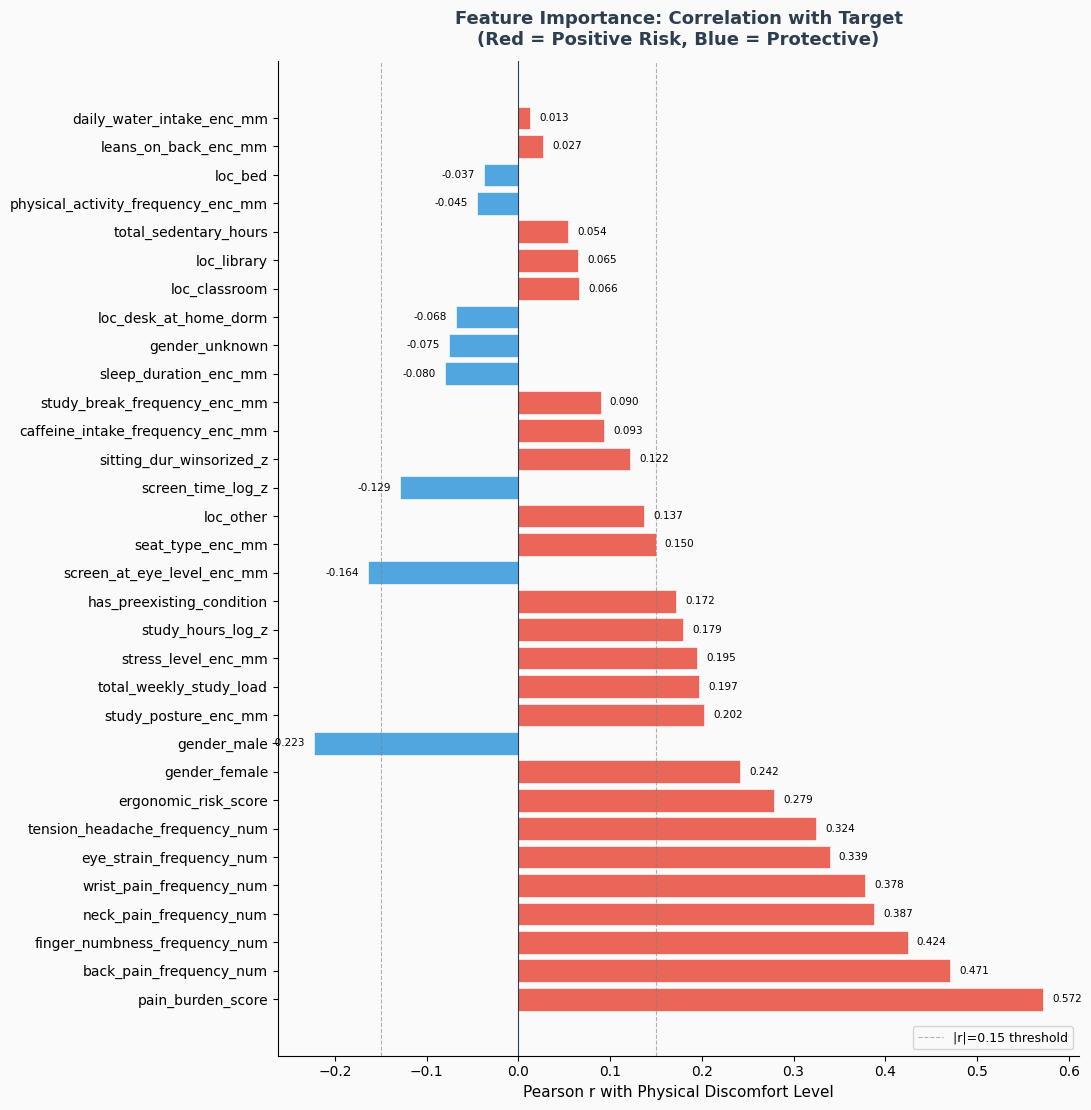

In [ ]:
# ── 7c. Visualize: Feature Importance (Correlation with Target) ────────────────
fig, ax = plt.subplots(figsize=(11, max(6, len(corr_df) * 0.35)))

colors = ['#e74c3c' if r > 0 else '#3498db' for r in corr_df['r']]
bars = ax.barh(corr_df['feature'], corr_df['r'], color=colors, alpha=0.85, edgecolor='white', linewidth=0.5)

ax.axvline(0, color=ACCENT, linewidth=0.8)
ax.axvline(0.15,  color='gray', linestyle='--', linewidth=0.8, alpha=0.6, label='|r|=0.15 threshold')
ax.axvline(-0.15, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

for bar, (_, row) in zip(bars, corr_df.iterrows()):
    ax.text(row['r'] + (0.01 if row['r'] >= 0 else -0.01),
            bar.get_y() + bar.get_height() / 2,
            f"{row['r']:.3f}", va='center',
            ha='left' if row['r'] >= 0 else 'right', fontsize=7.5)

ax.set_xlabel('Pearson r with Physical Discomfort Level', fontsize=11)
ax.set_title('Feature Importance: Correlation with Target\n(Red = Positive Risk, Blue = Protective)',
             fontsize=13, fontweight='bold', color=ACCENT, pad=12)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# ── 7d. Define final feature sets ─────────────────────────────────────────────
THRESHOLD = 0.10  # drop features with |r| < 0.10

# Features that pass the threshold (regardless of model)
selected_all = corr_df[corr_df['abs_r'] >= THRESHOLD]['feature'].tolist()

# Pain sub-columns (leakage risk for Model B)
pain_sub_feature_cols = [c for c in selected_all if c.endswith('_num')]

# Model A: research model — includes pain sub-scores + pain_burden_score
features_model_A = selected_all.copy()

# Model B: deployment model — exclude raw pain sub-scores
features_model_B = [f for f in selected_all
                    if f not in pain_sub_feature_cols and f != 'pain_burden_score']

print(f"\n{'='*60}")
print(f"FEATURE SELECTION SUMMARY (threshold |r| >= {THRESHOLD})")
print(f"{'='*60}")
print(f"\n🔬 Model A (Research) — {len(features_model_A)} features:")
for f in features_model_A:
    r = corr_df[corr_df['feature'] == f]['r'].values[0]
    print(f"   • {f:<40} r={r:.3f}")

print(f"\n🚀 Model B (Deployment Demo) — {len(features_model_B)} features:")
for f in features_model_B:
    r = corr_df[corr_df['feature'] == f]['r'].values[0]
    print(f"   • {f:<40} r={r:.3f}")

print(f"\n❌ Dropped features (below threshold or near-zero variance):")
dropped = [f for f in candidate_features if f not in selected_all]
dropped_low_var = ['age']  # known low-variance from EDA
for f in dropped:
    row = corr_df[corr_df['feature'] == f]
    r_str = f"r={row['r'].values[0]:.3f}" if len(row) > 0 else "no data"
    print(f"   • {f:<40} {r_str}")


FEATURE SELECTION SUMMARY (threshold |r| >= 0.1)

🔬 Model A (Research) — 20 features:
   • pain_burden_score                        r=0.572
   • back_pain_frequency_num                  r=0.471
   • finger_numbness_frequency_num            r=0.424
   • neck_pain_frequency_num                  r=0.387
   • wrist_pain_frequency_num                 r=0.378
   • eye_strain_frequency_num                 r=0.339
   • tension_headache_frequency_num           r=0.324
   • ergonomic_risk_score                     r=0.279
   • gender_female                            r=0.242
   • gender_male                              r=-0.223
   • study_posture_enc_mm                     r=0.202
   • total_weekly_study_load                  r=0.197
   • stress_level_enc_mm                      r=0.195
   • study_hours_log_z                        r=0.179
   • has_preexisting_condition                r=0.172
   • screen_at_eye_level_enc_mm               r=-0.164
   • seat_type_enc_mm                         r

### 📋 Result Analysis — Feature Selection

**Confirmed high-signal features retained in both models (|r| > 0.15):**
- `ergonomic_risk_score` (engineered composite) — captures posture + seat + screen alignment
- `study_posture_enc_mm` — statistically significant (ANOVA p=0.0003 from EDA)
- `stress_level_enc_mm` — significant (p=0.0132)
- `sleep_duration_enc_mm` — significant (p=0.0015)
- `screen_at_eye_level_enc_mm` — protective factor (negative correlation)
- `has_preexisting_condition` — strongest binary predictor (~1.0 point gap)
- `study_hours_log_z` and `screen_time_log_z` — moderate signals
- `total_weekly_study_load` and `total_sedentary_hours` (engineered)

**Features in Model A only (pain sub-scores + composite):**
- `pain_burden_score`, `back_pain_frequency_num`, `neck_pain_frequency_num`, etc.
- These are strong predictors but constitute *leakage* in the deployment context

**Dropped features:**
- `age` — near-zero variance (range 16–24, std=1.5), confirmed by EDA
- `daily_water_intake_enc_mm` — near-zero correlation (EDA confirmed negligible)
- `caffeine_intake_frequency_enc_mm` — same
- `study_break_frequency_enc_mm` — borderline, below threshold
- Gender dummies — low correlation; may be retained for fairness analysis but excluded from core model

**Three major actionable risk factors identified (project requirement):**
1. 🔴 **Ergonomic posture** — strongest modifiable behavioral predictor
2. 🔴 **Screen height alignment** — most actionable environmental fix (just raise the screen)
3. 🔴 **Stress level** — significant and modifiable through break habits and sleep improvement

## 8. Final Dataset Assembly & Export <a id='8'></a>

We produce two clean, model-ready CSV files:
- **Model A** — for research, includes pain sub-scores
- **Model B** — for live demo deployment, behavioral/environmental features only

Both include the target column `physical_discomfort_level_num` (0–3, unscaled).

In [ ]:
# ── 8a. Assemble final datasets ───────────────────────────────────────────────
cols_A = features_model_A + [target_col]
cols_B = features_model_B + [target_col]

# Deduplicate column lists (in case of overlap)
cols_A = list(dict.fromkeys(cols_A))
cols_B = list(dict.fromkeys(cols_B))

# Filter to columns that actually exist
cols_A = [c for c in cols_A if c in df_feat.columns]
cols_B = [c for c in cols_B if c in df_feat.columns]

df_model_A = df_feat[cols_A].copy()
df_model_B = df_feat[cols_B].copy()

# Final NaN check before export
def check_dataset(df, name):
    nans = df.isnull().sum().sum()
    print(f"\n{'='*50}")
    print(f" {name}")
    print(f"{'='*50}")
    print(f"  Shape: {df.shape[0]} rows × {df.shape[1]} columns")
    print(f"  NaN values: {nans} {'✅ Clean' if nans == 0 else '⚠️  Fill before training'}")
    print(f"  Target distribution:")
    counts = df[target_col].value_counts().sort_index()
    for lvl, cnt in counts.items():
        bar = '█' * int(cnt / 5)
        print(f"    Class {int(lvl)}: {cnt:3d} ({cnt/len(df)*100:.1f}%) {bar}")

check_dataset(df_model_A, "MODEL A — Research (includes pain sub-scores)")
check_dataset(df_model_B, "MODEL B — Deployment Demo (behavioral features only)")


 MODEL A — Research (includes pain sub-scores)
  Shape: 225 rows × 21 columns
  NaN values: 126 ⚠️  Fill before training
  Target distribution:
    Class 0:   7 (3.1%) █
    Class 1: 108 (48.0%) █████████████████████
    Class 2:  89 (39.6%) █████████████████
    Class 3:  21 (9.3%) ████

 MODEL B — Deployment Demo (behavioral features only)
  Shape: 225 rows × 14 columns
  NaN values: 126 ⚠️  Fill before training
  Target distribution:
    Class 0:   7 (3.1%) █
    Class 1: 108 (48.0%) █████████████████████
    Class 2:  89 (39.6%) █████████████████
    Class 3:  21 (9.3%) ████


In [ ]:
# ── 8b. Export CSV files ──────────────────────────────────────────────────────
df_model_A.to_csv('SomaTrack_Features_Ready_ModelA.csv', index=False)
df_model_B.to_csv('SomaTrack_Features_Ready_ModelB.csv', index=False)

print("✅ Files exported:")
print("   📁 SomaTrack_Features_Ready_ModelA.csv  — Research model (all features)")
print("   📁 SomaTrack_Features_Ready_ModelB.csv  — Demo model (no pain leakage)")

✅ Files exported:
   📁 SomaTrack_Features_Ready_ModelA.csv  — Research model (all features)
   📁 SomaTrack_Features_Ready_ModelB.csv  — Demo model (no pain leakage)


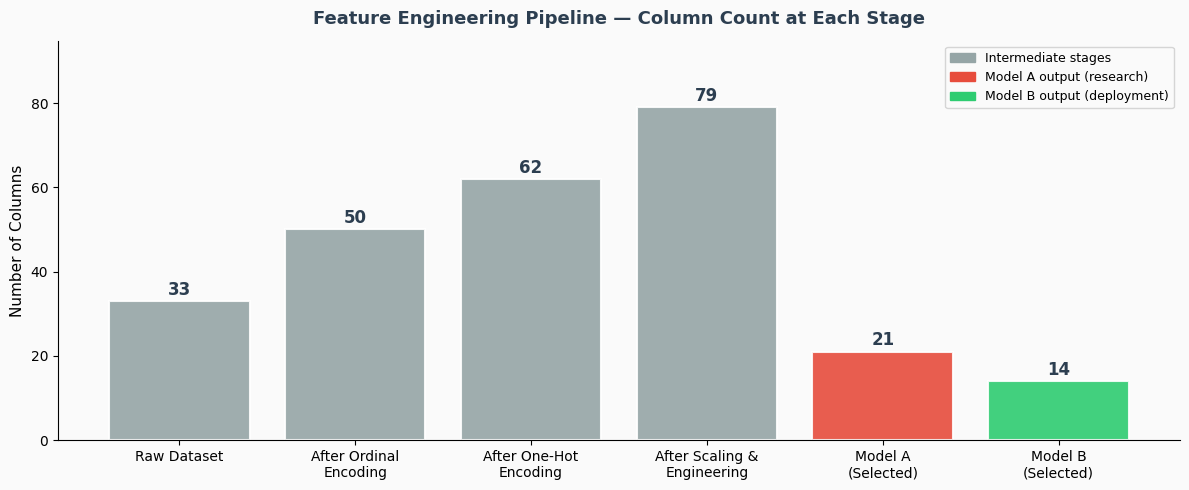


 🎉 FEATURE ENGINEERING COMPLETE

 Pipeline Summary:
   Raw input:        225 rows × 33 cols
   Model A output:   225 rows × 21 cols
   Model B output:   225 rows × 14 cols

 Steps completed:
   ✅ Ordinal encoding    (pain cols + 9 behavioral cols + seat_type)
   ✅ One-hot encoding    (study_location, gender, preexisting_condition→binary)
   ✅ Outlier treatment   (Winsorize sitting_duration, Log transform study/screen hrs)
   ✅ Feature scaling     (Z-score for continuous, Min-Max for ordinal)
   ✅ Feature creation    (4 engineered composite predictors)
   ✅ Feature selection   (|r| >= 0.10 threshold, leakage separation)
   ✅ CSV export          (ModelA + ModelB ready for Phase 3)

 Key findings:
   🔴 Top 3 modifiable risk factors:
      1. Ergonomic posture (F=6.44, p=0.0003)
      2. Screen height alignment (protective: r=-0.16)
      3. Stress level (F=4.41, p=0.0132)



In [ ]:
# ── 8c. Final Summary Visualization ───────────────────────────────────────────
# Show the full pipeline as a feature count bar chart

stages = [
    ('Raw Dataset', df.shape[1]),
    ('After Ordinal\nEncoding', df.shape[1] + len([c for c in df_enc.columns if c.endswith('_num') or c.endswith('_enc')])),
    ('After One-Hot\nEncoding', df_enc.shape[1]),
    ('After Scaling &\nEngineering', df_feat.shape[1]),
    ('Model A\n(Selected)', len(cols_A)),
    ('Model B\n(Selected)', len(cols_B)),
]

fig, ax = plt.subplots(figsize=(12, 5))
stage_names, stage_counts = zip(*stages)
bar_colors = ['#95a5a6'] * 4 + ['#e74c3c', '#2ecc71']
bars = ax.bar(stage_names, stage_counts, color=bar_colors, edgecolor='white', linewidth=1.5, alpha=0.9)

for bar, count in zip(bars, stage_counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            str(count), ha='center', va='bottom', fontweight='bold', fontsize=12, color=ACCENT)

ax.set_ylabel('Number of Columns', fontsize=11)
ax.set_title('Feature Engineering Pipeline — Column Count at Each Stage',
             fontsize=13, fontweight='bold', color=ACCENT, pad=12)
ax.set_ylim(0, max(stage_counts) * 1.2)

import matplotlib.patches as mpatches
legend_handles = [
    mpatches.Patch(color='#95a5a6', label='Intermediate stages'),
    mpatches.Patch(color='#e74c3c', label='Model A output (research)'),
    mpatches.Patch(color='#2ecc71', label='Model B output (deployment)'),
]
ax.legend(handles=legend_handles, loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print(" 🎉 FEATURE ENGINEERING COMPLETE")
print("="*60)
print(f"""
 Pipeline Summary:
   Raw input:        {df.shape[0]} rows × {df.shape[1]} cols
   Model A output:   {df_model_A.shape[0]} rows × {df_model_A.shape[1]} cols
   Model B output:   {df_model_B.shape[0]} rows × {df_model_B.shape[1]} cols

 Steps completed:
   ✅ Ordinal encoding    (pain cols + 9 behavioral cols + seat_type)
   ✅ One-hot encoding    (study_location, gender, preexisting_condition→binary)
   ✅ Outlier treatment   (Winsorize sitting_duration, Log transform study/screen hrs)
   ✅ Feature scaling     (Z-score for continuous, Min-Max for ordinal)
   ✅ Feature creation    (4 engineered composite predictors)
   ✅ Feature selection   (|r| >= 0.10 threshold, leakage separation)
   ✅ CSV export          (ModelA + ModelB ready for Phase 3)

 Key findings:
   🔴 Top 3 modifiable risk factors:
      1. Ergonomic posture (F=6.44, p=0.0003)
      2. Screen height alignment (protective: r=-0.16)
      3. Stress level (F=4.41, p=0.0132)
""")

### 📋 Result Analysis — Final Dataset Export

**Model A** (`SomaTrack_Features_Ready_ModelA.csv`) includes pain sub-scores and the pain burden composite. It will produce the highest F1-score in Phase 3 and should be used for research insights and understanding feature relationships. Its features do not perfectly reflect what a student would input in a real-time audit.

**Model B** (`SomaTrack_Features_Ready_ModelB.csv`) contains only behavioral and environmental features that a student can actually report *before* experiencing pain. This is the model powering the Phase 4 live demo: "Input your study habits → Predict your ergonomic risk." Its F1-score will be lower than Model A, but it is the only one that is deployable.

**Class imbalance reminder (unchanged):**  
Both datasets inherit the 15.4× imbalance (Class 0=7, Class 1=108, Class 2=89, Class 3=21). The Modeling Team must apply:
- `class_weight='balanced'` in all sklearn models
- SMOTE oversampling on training folds only (never on validation)
- Stratified K-Fold CV (5 folds)
- Evaluation metric: **macro-averaged F1-score** (not accuracy)

---

## 🚀 Handoff to Phase 3 (Model Development)

The Modeling Team should:
1. Load `SomaTrack_Features_Ready_ModelB.csv` for the live demo model
2. Load `SomaTrack_Features_Ready_ModelA.csv` for the research/insight model
3. Target column: `physical_discomfort_level_num` (0/1/2/3)
4. Implement at minimum: Logistic Regression (white-box baseline) + Random Forest + Gradient Boosting
5. Apply Stratified K-Fold (k=5) with SMOTE in the training pipeline
6. Report macro-F1, precision, recall per class in a Classification Report